In [1]:
import pandas as pd
import numpy as np
import openpyxl

In [2]:
!pip install openpyxl

In [21]:
cargo_freqawal = pd.read_excel(
    "/content/cargoloss.xlsx",
    engine="openpyxl", sheet_name ="Freq"
)

In [4]:
cargo_sev = pd.read_excel(
    "/content/cargoloss.xlsx", sheet_name ="Sev"
)

In [5]:
cargo_sev = cargo_sev.iloc[:, :-4]
cargo_sev.columns

Index(['claim_id', 'claim_seq', 'cargo_value', 'weight', 'route_risk',
       'distance', 'transit_duration', 'pilot_experience', 'vessel_age',
       'solar_radiation', 'debris_density', 'exposure', 'claim_amount',
       'cargo_type_clean', 'container_type_clean', 'policy_id_clean',
       'shipment_id_clean'],
      dtype='object')

In [22]:
cargo_freqawal.columns

Index(['cargo_value', 'weight', 'route_risk', 'distance', 'transit_duration',
       'pilot_experience', 'vessel_age', 'solar_radiation', 'debris_density',
       'exposure', 'cargo_type_clean', 'container_type_clean',
       'policy_id_clean', 'shipment_id_clean', 'claim_count_same'],
      dtype='object')

In [23]:
# cargo_freq
cargo_freqawal = cargo_freqawal.drop(
    columns=["policy_id_clean", "shipment_id_clean"],
    errors="ignore"
)

# cargo_sev
cargo_sev = cargo_sev.drop(
    columns=["policy_id_clean", "shipment_id_clean", "claim_id"],
    errors="ignore"
)

In [24]:
def missing_summary(df, dataset_name):
    total_rows = len(df)
    summary = pd.DataFrame({
        "Dataset": dataset_name,
        "Kolom": df.columns,
        "Missing Count": df.isna().sum().values,
        "Missing (%)": (df.isna().sum() / total_rows * 100).values
    })
    return summary

# Buat ringkasan missing
missing_freq = missing_summary(cargo_freqawal, "cargo_freq")
missing_sev  = missing_summary(cargo_sev, "cargo_sev")

# Gabungkan
missing_all = pd.concat([missing_freq, missing_sev], ignore_index=True)

# Tampilkan hanya kolom yang benar-benar missing
missing_all = missing_all[missing_all["Missing Count"] > 0]

missing_all

,Dataset,Kolom,Missing Count,Missing (%)
0,cargo_freq,cargo_value,417,0.333648
1,cargo_freq,weight,401,0.320846
2,cargo_freq,route_risk,480,0.384055
3,cargo_freq,distance,468,0.374454
4,cargo_freq,transit_duration,392,0.313645
5,cargo_freq,pilot_experience,497,0.397657
6,cargo_freq,vessel_age,461,0.368853
7,cargo_freq,solar_radiation,515,0.412059
8,cargo_freq,debris_density,453,0.362452
9,cargo_freq,exposure,474,0.379255


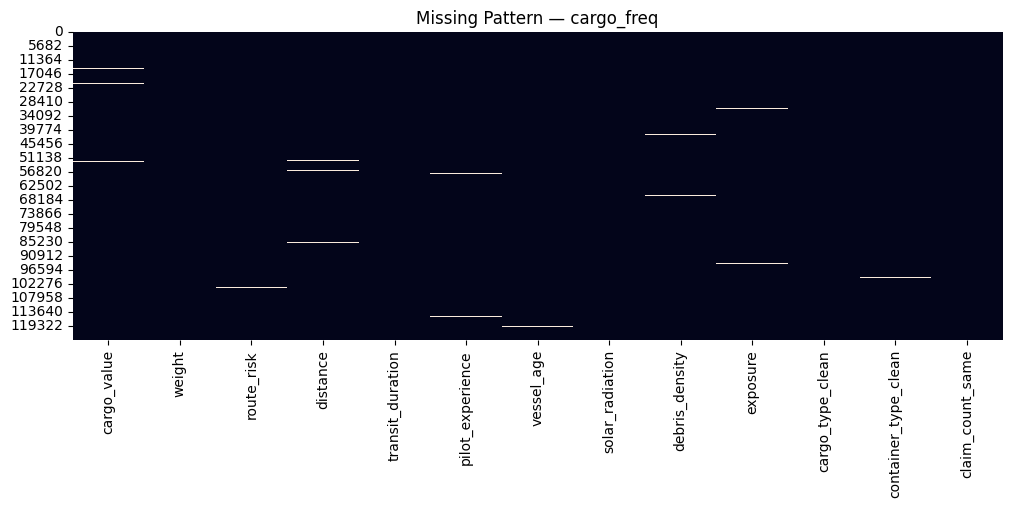

In [25]:
# Melihat apakah missing barengan ?
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,4))
sns.heatmap(cargo_freqawal.isna(), cbar=False)
plt.title("Missing Pattern — cargo_freq")
plt.show()

In [26]:
def missing_vs_outcome(df, outcome):
    res = []
    for col in df.columns:
        if df[col].isna().sum() > 0:
            res.append({
                "variable": col,
                "outcome_missing": df.loc[df[col].isna(), outcome].mean(),
                "outcome_not_missing": df.loc[df[col].notna(), outcome].mean()
            })
    return pd.DataFrame(res)

missing_vs_outcome(cargo_freqawal, outcome="claim_count_same")

,variable,outcome_missing,outcome_not_missing
0,cargo_value,0.000000,0.246056
1,weight,0.002494,0.246017
2,route_risk,0.002083,0.246173
3,distance,0.012821,0.246109
4,transit_duration,0.002551,0.245999
5,pilot_experience,0.046278,0.246030
6,vessel_age,0.000000,0.246143
7,solar_radiation,0.000000,0.246250
8,debris_density,0.000000,0.246127
9,exposure,0.000000,0.246169


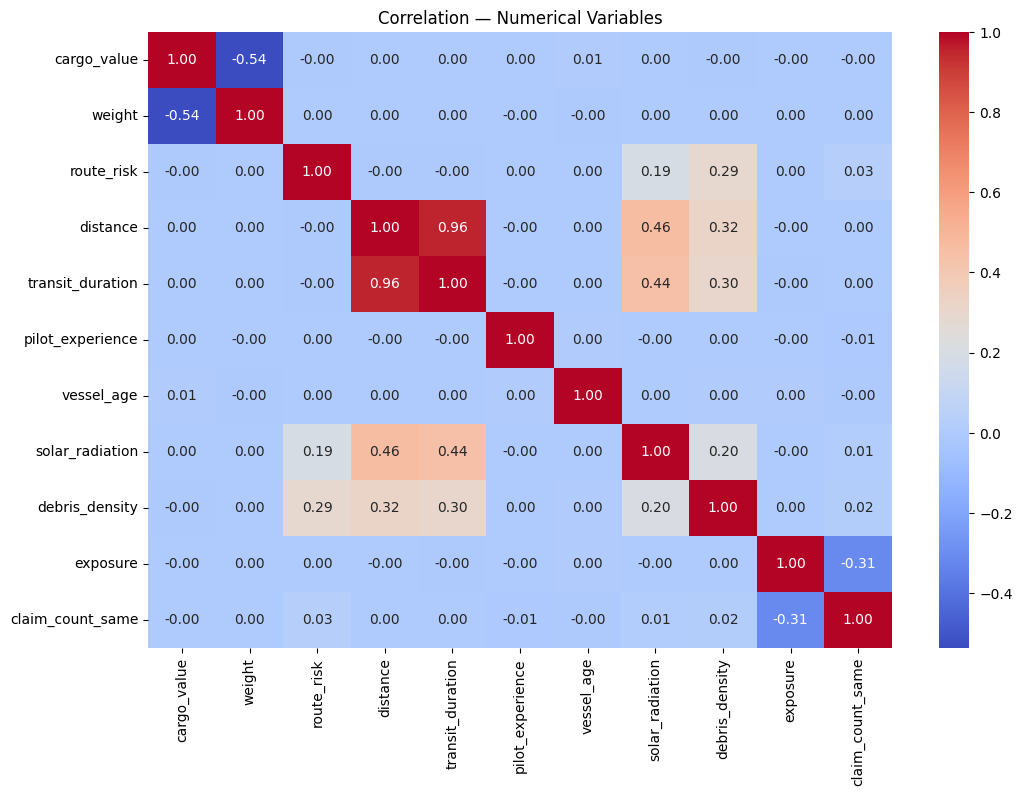

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# ambil semua variabel numerik
num_vars = cargo_freqawal.select_dtypes(include=["int64", "float64"]).columns

# hitung korelasi
corr = cargo_freqawal[num_vars].corr()

# plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation — Numerical Variables")
plt.show()

In [55]:
cargo_freqawal

,cargo_value,weight,route_risk,distance,transit_duration,pilot_experience,vessel_age,solar_radiation,debris_density,exposure,cargo_type_clean,container_type_clean,claim_count_same
0,11070000.0,135000.0,4.0,NaN,6.619,18.017,19.380,0.288,0.127,0.340,lithium,QuantumCrate Module,0
1,8320000.0,160000.0,5.0,33.69,20.794,12.828,6.305,0.255,0.296,0.148,cobalt,DockArc Freight Case,3
2,12300000.0,150000.0,1.0,10.93,6.445,6.039,31.811,0.076,0.252,0.289,lithium,QuantumCrate Module,0
3,500000.0,50000.0,4.0,13.49,9.583,17.533,9.695,0.150,0.350,0.813,supplies,DockArc Freight Case,0
4,2550000.0,30000.0,3.0,1.58,1.000,17.157,19.357,0.149,0.000,0.959,rare earths,DeepSpace Haulbox,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
124977,1750000.0,250000.0,2.0,1.58,1.000,15.323,19.682,0.226,0.209,0.337,titanium,LongHaul Vault Canister,0
124978,2550000.0,30000.0,3.0,25.77,15.370,17.426,33.249,0.234,0.153,0.748,rare earths,DockArc Freight Case,0
124979,8610000.0,105000.0,3.0,25.67,11.497,12.446,19.711,0.152,0.213,0.530,lithium,DockArc Freight Case,0
124980,610200000.0,4500.0,2.0,40.37,36.080,7.297,33.932,0.295,0.267,0.430,gold,LongHaul Vault Canister,0


In [61]:
import numpy as np

num_cols = cargo_freqawal.select_dtypes(include=np.number)

stats = num_cols.describe().T[['min','mean','50%','max']]
stats = stats.rename(columns={'50%':'median'})

stats = stats.round(4)

print(stats)

                         min          mean       median           max
cargo_value       500000.000  9.318784e+07  6240000.000  6.780000e+08
weight              1500.000  8.125996e+04    75000.000  2.500000e+05
route_risk             1.000  2.991500e+00        3.000  5.000000e+00
distance               1.580  2.621660e+01       25.020  9.979000e+01
transit_duration       1.000  1.574140e+01       14.617  6.000000e+01
pilot_experience       1.000  1.500390e+01       15.006  3.000000e+01
vessel_age             1.000  2.008360e+01       19.956  5.000000e+01
solar_radiation        0.000  2.391000e-01        0.237  9.676000e-01
debris_density         0.000  2.425000e-01        0.242  9.927000e-01
exposure               0.083  5.000000e-01        0.499  9.990000e-01
claim_count_same       0.000  2.452000e-01        0.000  5.000000e+00


In [56]:
pd.crosstab(cargo_freqawal['cargo_type_clean'], cargo_freqawal['route_risk'], normalize='index')

route_risk,1.0,2.0,3.0,4.0,5.0
cargo_type_clean,,,,,
cobalt,0.101132,0.201532,0.394729,0.200462,0.102145
gold,0.101653,0.202347,0.405088,0.194393,0.096519
lithium,0.106043,0.200738,0.398638,0.197957,0.096624
platinum,0.103981,0.201928,0.399177,0.199278,0.095636
rare earths,0.098744,0.201149,0.399087,0.198783,0.102236
supplies,0.100651,0.193949,0.403727,0.198608,0.103065
titanium,0.096420,0.208863,0.402375,0.197826,0.094515


In [28]:
cargo_freqawal[anchor_vars].describe()

,weight,distance,transit_duration,exposure,pilot_experience
count,124581.000000,124514.000000,124590.000000,124508.000000,124485.000000
mean,81259.957394,26.216593,15.741434,0.499957,15.003911
std,70914.225686,17.942612,11.200831,0.222941,4.988954
min,1500.000000,1.580000,1.000000,0.083000,1.000000
25%,4500.000000,11.580000,6.684250,0.325000,11.632000
50%,75000.000000,25.020000,14.617000,0.499000,15.006000
75%,135000.000000,38.550000,22.998750,0.673000,18.382000
max,250000.000000,99.790000,60.000000,0.999000,30.000000


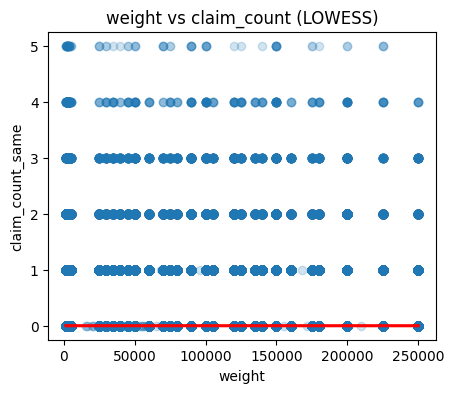

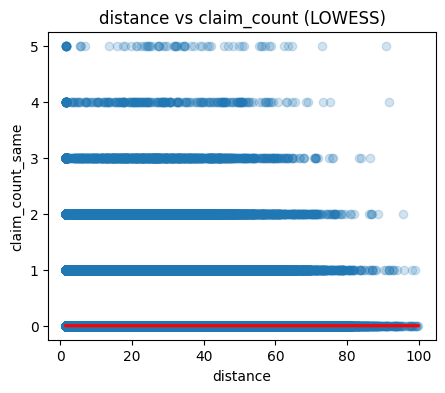

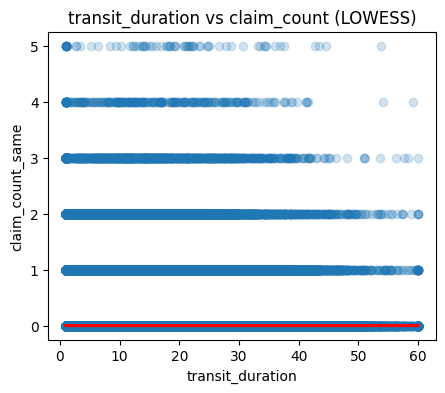

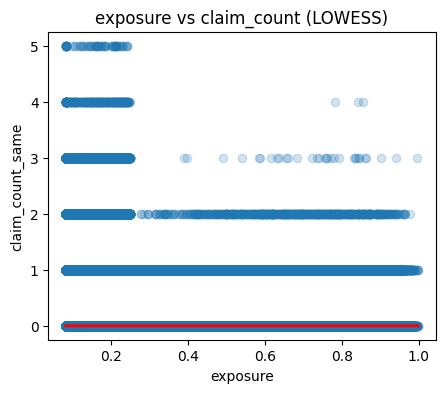

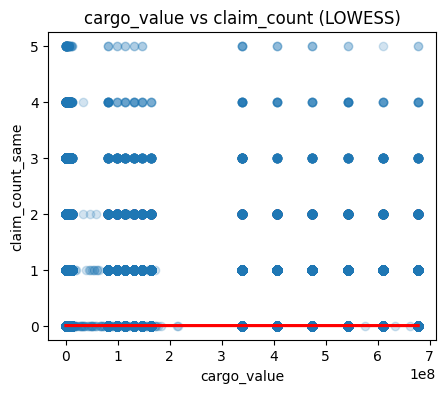

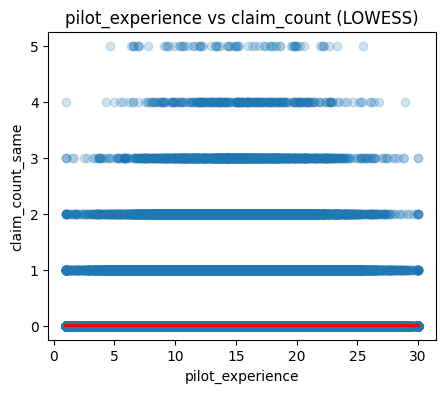

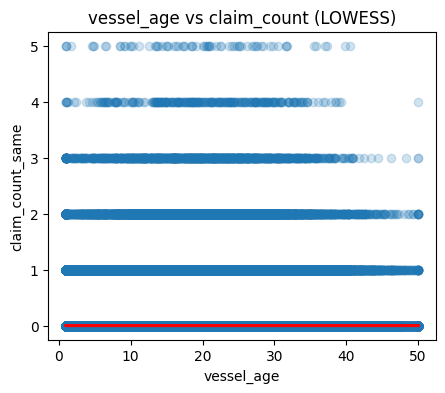

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_vars = [
    "weight", "distance", "transit_duration",
    "exposure", "cargo_value", "pilot_experience", "vessel_age"
]

for col in num_vars:
    plt.figure(figsize=(5,4))
    sns.regplot(
        x=cargo_freqawal[col],
        y=cargo_freqawal["claim_count_same"],
        lowess=True,
        scatter_kws={"alpha":0.2},
        line_kws={"color":"red"}
    )
    plt.title(f"{col} vs claim_count (LOWESS)")
    plt.show()

In [ ]:
import statsmodels.api as sm
import numpy as np

df = cargo_freqawal[["distance", "claim_count_same"]].dropna()

# Linear
X_lin = sm.add_constant(df["distance"])
model_lin = sm.GLM(df["claim_count_same"], X_lin, family=sm.families.Poisson()).fit()

# Quadratic
df["distance_sq"] = df["distance"]**2
X_quad = sm.add_constant(df[["distance", "distance_sq"]])
model_quad = sm.GLM(df["claim_count_same"], X_quad, family=sm.families.Poisson()).fit()

print("Linear AIC:", model_lin.aic)
print("Quadratic AIC:", model_quad.aic)

dri hasil diatas dpt disimpulkan bahwa cara imputasi gmnpun ga berpengaruh besar. Jadi pake MICE aja

1. Hubungan yang Sangat Lemah (Low Correlation)
Garis LOWESS yang mendatar menunjukkan bahwa variabel-variabel independenmu (weight, distance, transit_duration, dll.) secara individual tidak memiliki hubungan linear maupun non-linear yang kuat terhadap claim_count_same.

Artinya: Perubahan pada berat atau jarak tempuh tidak secara otomatis menaikkan atau menurunkan jumlah klaim secara signifikan.

2. Sinyal untuk Model Linear
Hasil ini selaras dengan nilai AIC yang kamu dapatkan sebelumnya. Karena garis LOWESS tidak menunjukkan lekukan (curvatures) yang ekstrem (seperti bentuk U atau S), maka model Linear adalah pendekatan yang paling jujur.

Pesan untuk Lomba: "Jangan memaksa menggunakan model kompleks (Deep Learning/Polynomial) jika data menunjukkan hubungan yang sederhana. Model yang lebih sederhana akan memiliki generalization yang lebih baik."

3. Fenomena "Imbalance" pada Target
Data claim_count_same kamu terlihat sangat menumpuk di angka 0. Ini adalah tipikal data klaim asuransi atau logistik (zero-inflated data). Kebanyakan pengiriman tidak memiliki klaim, dan hanya segelintir yang memiliki klaim 1-5.

Alasan penggunaan MICE dripada median :
1. Preservasi Hubungan Multivariat (Preserving Inter-variable Relationships)
Median imputation hanya melihat satu kolom (univariat). Jika kamu mengisi cargo_value yang hilang dengan median, nilai tersebut tidak akan peduli apakah distance-nya jauh atau dekat.

Justifikasi: MICE menjaga korelasi antar fitur. Ia mengisi nilai berdasarkan prediksi dari variabel lain, sehingga hubungan logis (misal: jarak jauh cenderung memiliki biaya/risiko lebih tinggi) tetap terjaga di baris yang diimputasi.

2. Mempertahankan Varians dan Distribusi (Maintaining Variance)
Median imputation cenderung membuat "lonjakan" (spike) pada distribusi data karena ratusan data kosong diisi dengan satu angka yang sama persis. Ini memperkecil standar deviasi secara artifisial.

Justifikasi: MICE menambahkan sedikit ketidakpastian (stochastic element) dalam proses iterasinya. Hal ini memastikan distribusi data hasil imputasi tetap menyerupai distribusi aslinya dan tidak bias (tidak menumpuk di satu titik tengah saja).

3. Mengurangi Bias Estimasi (Reducing Bias)
Median hanya akurat jika data hilang secara benar-benar acak tanpa pola (MCAR). Namun, jika ada pola sedikit saja (MAR), Median akan memberikan hasil yang bias.

Justifikasi: Karena MICE bersifat iteratif dan menggunakan informasi dari kolom lain, ia jauh lebih efektif dalam menangani mekanisme Missing At Random (MAR), yang sering ditemui dalam data riil di industri.

# Imputation

In [120]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.linear_model import BayesianRidge

In [121]:
cargo_freq = cargo_freqawal.copy()

In [122]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import numpy as np

dist_vars = [
    "distance",
    "weight",
    "cargo_value",
    "pilot_experience",
    "vessel_age",
    "solar_radiation",
    "debris_density",
    "exposure"
]

dist_min = cargo_freq[dist_vars].min().values
dist_max = cargo_freq[dist_vars].max().values

imp_dist = IterativeImputer(
    max_iter=20,
    random_state=42,
    estimator=BayesianRidge(),
    initial_strategy="median",
    min_value=dist_min,
    max_value=dist_max
)

cargo_freq[dist_vars] = imp_dist.fit_transform(cargo_freq[dist_vars])

In [123]:
transit_vars = [
    "transit_duration",
    "distance",
    "weight",
    "cargo_value",
    "pilot_experience",
    "vessel_age",
    "solar_radiation",
    "debris_density",
    "exposure"
]

transit_min = cargo_freq[transit_vars].min().values
transit_max = cargo_freq[transit_vars].max().values

imp_transit = IterativeImputer(
    max_iter=20,
    random_state=42,
    estimator=BayesianRidge(),
    initial_strategy="median",
    min_value=transit_min,
    max_value=transit_max
)

cargo_freq[transit_vars] = imp_transit.fit_transform(cargo_freq[transit_vars])

In [124]:
num_cols = [
    "cargo_value",
    "weight",
    "pilot_experience",
    "vessel_age",
    "solar_radiation",
    "debris_density",
    "exposure"
]

num_min = cargo_freq[num_cols].min().values
num_max = cargo_freq[num_cols].max().values

imp_other = IterativeImputer(
    max_iter=20,
    random_state=42,
    initial_strategy="median",
    estimator=BayesianRidge(),
    min_value=num_min,
    max_value=num_max
)

cargo_freq[num_cols] = imp_other.fit_transform(cargo_freq[num_cols])

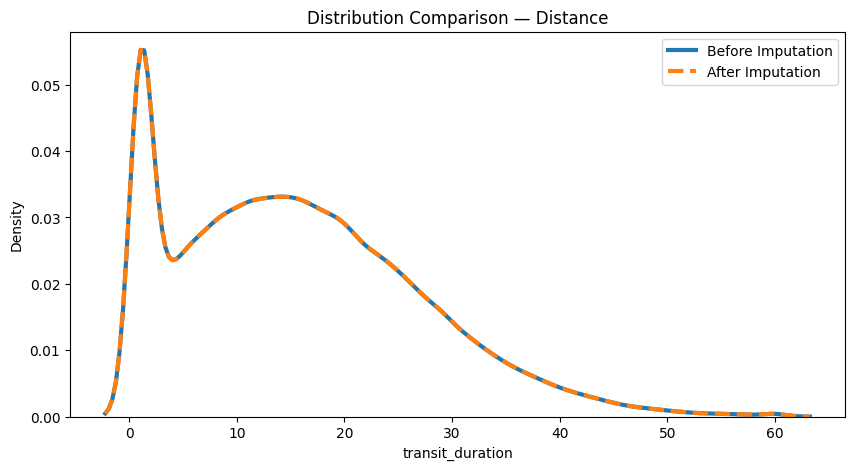

In [125]:
plt.figure(figsize=(10,5))

sns.kdeplot(cargo_freqawal["transit_duration"],
            label="Before Imputation",
            linewidth=3)

sns.kdeplot(cargo_freq["transit_duration"],
            label="After Imputation",
            linewidth=3,
            linestyle="--")

plt.title("Distribution Comparison — Distance")
plt.legend()
plt.show()

In [126]:
cargo_freq.describe()


,cargo_value,weight,route_risk,distance,transit_duration,pilot_experience,vessel_age,solar_radiation,debris_density,exposure,claim_count_same
count,1.249820e+05,124982.000000,124502.000000,124982.000000,124982.000000,124982.000000,124982.000000,124982.000000,124982.000000,124982.000000,124982.000000
mean,9.323750e+07,81283.678380,2.991518,26.216241,15.746672,15.003911,20.083559,0.239152,0.242515,0.499957,0.245235
std,1.794816e+08,70818.544773,1.095107,17.917600,11.199819,4.979024,9.730240,0.113766,0.109539,0.222518,0.591974
min,5.000000e+05,1500.000000,1.000000,1.580000,1.000000,1.000000,1.000000,0.000000,0.000000,0.083000,0.000000
25%,1.575000e+06,4500.000000,2.000000,11.630000,6.694000,11.647000,13.245250,0.161000,0.168000,0.326000,0.000000
50%,6.240000e+06,75000.000000,3.000000,25.020000,14.625000,15.004964,20.003000,0.237000,0.242000,0.499000,0.000000
75%,9.810000e+07,135000.000000,4.000000,38.510000,23.004750,18.364000,26.695000,0.316000,0.316000,0.673000,0.000000
max,6.780000e+08,250000.000000,5.000000,99.790000,60.000000,30.000000,50.000000,0.967636,0.992747,0.999000,5.000000


In [127]:
cargo_freq.describe()

,cargo_value,weight,route_risk,distance,transit_duration,pilot_experience,vessel_age,solar_radiation,debris_density,exposure,claim_count_same
count,1.249820e+05,124982.000000,124502.000000,124982.000000,124982.000000,124982.000000,124982.000000,124982.000000,124982.000000,124982.000000,124982.000000
mean,9.323750e+07,81283.678380,2.991518,26.216241,15.746672,15.003911,20.083559,0.239152,0.242515,0.499957,0.245235
std,1.794816e+08,70818.544773,1.095107,17.917600,11.199819,4.979024,9.730240,0.113766,0.109539,0.222518,0.591974
min,5.000000e+05,1500.000000,1.000000,1.580000,1.000000,1.000000,1.000000,0.000000,0.000000,0.083000,0.000000
25%,1.575000e+06,4500.000000,2.000000,11.630000,6.694000,11.647000,13.245250,0.161000,0.168000,0.326000,0.000000
50%,6.240000e+06,75000.000000,3.000000,25.020000,14.625000,15.004964,20.003000,0.237000,0.242000,0.499000,0.000000
75%,9.810000e+07,135000.000000,4.000000,38.510000,23.004750,18.364000,26.695000,0.316000,0.316000,0.673000,0.000000
max,6.780000e+08,250000.000000,5.000000,99.790000,60.000000,30.000000,50.000000,0.967636,0.992747,0.999000,5.000000


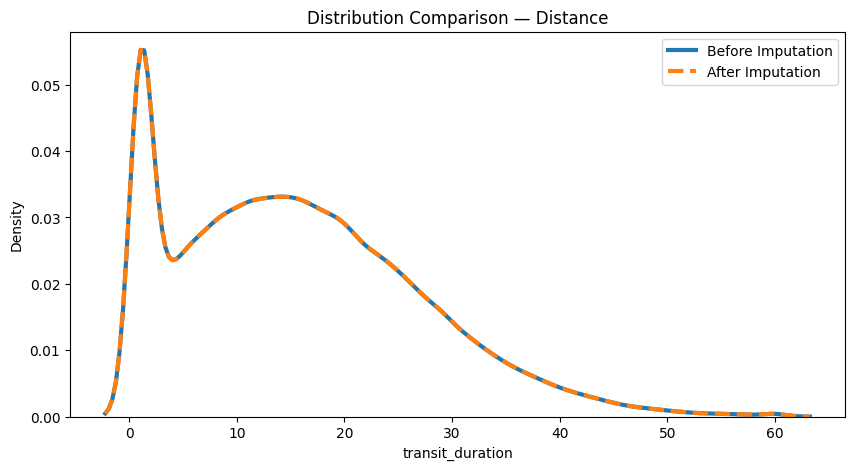

In [128]:
plt.figure(figsize=(10,5))

sns.kdeplot(cargo_freqawal["transit_duration"],
            label="Before Imputation",
            linewidth=3)

sns.kdeplot(cargo_freq["transit_duration"],
            label="After Imputation",
            linewidth=3,
            linestyle="--")

plt.title("Distribution Comparison — Distance")
plt.legend()
plt.show()

# Kategorik Imputation

In [129]:
cargo_freq['route_risk'] = cargo_freq['route_risk'].astype('category')

In [130]:
cargo_freq['cargo_type_clean'] = cargo_freq.groupby(
    'container_type_clean'
)['cargo_type_clean'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

In [131]:
cargo_freq['container_type_clean'] = cargo_freq.groupby(
    'cargo_type_clean'
)['container_type_clean'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

In [132]:
cargo_freq['cargo_type_clean'] = cargo_freq['cargo_type_clean'].fillna(
    cargo_freq['cargo_type_clean'].mode()[0]
)

cargo_freq['container_type_clean'] = cargo_freq['container_type_clean'].fillna(
    cargo_freq['container_type_clean'].mode()[0]
)

In [133]:
cargo_freq['route_risk'] = cargo_freq.groupby(
    ['cargo_type_clean','container_type_clean']
)['route_risk'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

cargo_freq['route_risk'] = cargo_freq['route_risk'].fillna(
    cargo_freq['route_risk'].mode()[0]
)

In [134]:
cargo_freq.isna().sum()

,0
cargo_value,0
weight,0
route_risk,0
distance,0
transit_duration,0
pilot_experience,0
vessel_age,0
solar_radiation,0
debris_density,0
exposure,0


# Imputasi Severity

In [140]:
cargo_sev = cargo_sev.drop(columns=['claim_seq'])

In [141]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

num_vars = [
    "cargo_value",
    "weight",
    "distance",
    "transit_duration",
    "pilot_experience",
    "vessel_age",
    "solar_radiation",
    "debris_density",
    "exposure"
]

imp_mice = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=20,
    random_state=42,
    initial_strategy="median"
)

cargo_sev[num_vars] = imp_mice.fit_transform(cargo_sev[num_vars])

In [142]:
cargo_sev['route_risk'] = cargo_sev.groupby(
    ['cargo_type_clean','container_type_clean']
)['route_risk'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
)

In [143]:
cargo_sev.isna().sum()

,0
cargo_value,0
weight,0
route_risk,0
distance,0
transit_duration,0
pilot_experience,0
vessel_age,0
solar_radiation,0
debris_density,0
exposure,0


# Download data

In [144]:
with pd.ExcelWriter("cargo_dataset_clean.xlsx") as writer:
    cargo_freq.to_excel(writer, sheet_name="cargo_frequency", index=False)
    cargo_sev.to_excel(writer, sheet_name="cargo_severity", index=False)

#